# Phase 3: Business Intelligence & Performance Correlation

In [1]:
from sqlalchemy import create_engine

# 1. Define your SQL Server details

In [2]:
server_name = 'Your_Server_Name' # This depends on your setup!
database_name = 'LibertyAnalytics'

# 5. Create the connection string

In [3]:
connection_string = f"mssql+pyodbc://@{server_name}/{database_name}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
engine = create_engine(connection_string)

# 3. Run SQL Queries on the Database

## Which NY Liberty players average the most points during Away games in the month of August?

In [4]:
import pandas as pd

print("Executing complex Star Schema query...")

# The ultimate test of your new database architecture
complex_query = """
    SELECT 
        p.PLAYER_NAME,
        COUNT(fps.GAME_ID) AS Games_Played,
        ROUND(AVG(CAST(fps.Points AS FLOAT)), 1) AS Avg_Points,
        ROUND(AVG(CAST(fps.Assists AS FLOAT)), 1) AS Avg_Assists,
        ROUND(AVG(CAST(fps.Rebounds AS FLOAT)), 1) AS Avg_Rebounds
    FROM Fact_Player_Stats fps
    JOIN Dim_Players p 
        ON fps.PLAYER_ID = p.PLAYER_ID
    JOIN Dim_Teams t 
        ON p.TEAM_ID = t.TEAM_ID
    JOIN Fact_Games fg 
        ON fps.GAME_ID = fg.GAME_ID
    JOIN Dim_Dates d 
        ON fg.GAME_DATE = d.GAME_DATE
    WHERE t.TEAM_ABBREVIATION = 'NYL' 
      AND fg.MATCHUP LIKE '%@%'    -- The '@' symbol in the matchup string means it's an away game!
      AND d.Game_Month = '08'      -- Filtering for the late-season month of August
    GROUP BY p.PLAYER_NAME
    HAVING COUNT(fps.GAME_ID) >= 5 -- Only include players who have played at least 5 of these games
    ORDER BY Avg_Points DESC;
"""

# Run the query and load the results into a dataframe
with engine.connect() as conn:
    df_results = pd.read_sql(complex_query, conn)

print("\n--- NY Liberty: Top Away-Game Performers in August (2021-2025) ---")
print(df_results.to_string(index=False))

Executing complex Star Schema query...

--- NY Liberty: Top Away-Game Performers in August (2021-2025) ---
            PLAYER_NAME  Games_Played  Avg_Points  Avg_Assists  Avg_Rebounds
        Breanna Stewart            31        22.1          3.3           9.2
        Sabrina Ionescu            41        17.3          5.1           5.5
          Jonquel Jones            43        14.6          2.4           9.5
         Natasha Howard            42        14.0          2.3           7.1
         Emma Meesseman            19        13.3          3.8           5.2
Betnijah Laney-Hamilton            25        12.4          3.3           3.8
      Layshia Clarendon            15        10.7          4.3           3.0
          Natasha Cloud            43        10.3          5.4           3.6
   Courtney Vandersloot            31        10.1          7.4           3.5
         Leonie Fiebich            22         8.4          2.2           3.6
          Sami Whitcomb            42         

## How much does playing at the Barclays Center actually impact the Liberty's win rate year over year?

In [5]:
# Query 1: Home vs. Away Win Percentage
query_home_court = """
    SELECT 
        d.Game_Year,
        COUNT(fg.GAME_ID) AS Total_Games,
        -- Calculate Home Win Percentage
        ROUND(
            SUM(CASE WHEN fg.MATCHUP NOT LIKE '%@%' AND fg.Win_Loss = 'W' THEN 1.0 ELSE 0.0 END) / 
            NULLIF(SUM(CASE WHEN fg.MATCHUP NOT LIKE '%@%' THEN 1.0 ELSE 0.0 END), 0) * 100
        , 1) AS Home_Win_Pct,
        -- Calculate Away Win Percentage
        ROUND(
            SUM(CASE WHEN fg.MATCHUP LIKE '%@%' AND fg.Win_Loss = 'W' THEN 1.0 ELSE 0.0 END) / 
            NULLIF(SUM(CASE WHEN fg.MATCHUP LIKE '%@%' THEN 1.0 ELSE 0.0 END), 0) * 100
        , 1) AS Away_Win_Pct
    FROM Fact_Games fg
    JOIN Dim_Teams t ON fg.TEAM_ID = t.TEAM_ID
    JOIN Dim_Dates d ON fg.GAME_DATE = d.GAME_DATE
    WHERE t.TEAM_ABBREVIATION = 'NYL'
    GROUP BY d.Game_Year
    ORDER BY d.Game_Year DESC;
"""

with engine.connect() as conn:
    print("--- NY Liberty: Home vs Away Win Percentage by Year ---")
    print(pd.read_sql(query_home_court, conn).to_string(index=False))

--- NY Liberty: Home vs Away Win Percentage by Year ---
Game_Year  Total_Games  Home_Win_Pct  Away_Win_Pct
     2025           44          77.3          45.5
     2024           40          80.0          80.0
     2023           40          75.0          85.0
     2022           36          50.0          38.9
     2021           32          43.8          31.3


## Who was the number one top-scoring player for the Liberty in each of the last 5 seasons?

In [6]:
# Query 2: Year-over-Year Top Scorers using Window Functions
query_top_scorers = """
    WITH YearlyPlayerStats AS (
        SELECT 
            p.PLAYER_NAME,
            d.Game_Year,
            SUM(CAST(fps.Points AS FLOAT)) AS Total_Season_Points,
            -- This ranks players 1, 2, 3... within each specific year based on points
            ROW_NUMBER() OVER(PARTITION BY d.Game_Year ORDER BY SUM(CAST(fps.Points AS FLOAT)) DESC) as Team_Rank
        FROM Fact_Player_Stats fps
        JOIN Dim_Players p ON fps.PLAYER_ID = p.PLAYER_ID
        JOIN Dim_Teams t ON p.TEAM_ID = t.TEAM_ID
        JOIN Fact_Games fg ON fps.GAME_ID = fg.GAME_ID
        JOIN Dim_Dates d ON fg.GAME_DATE = d.GAME_DATE
        WHERE t.TEAM_ABBREVIATION = 'NYL'
        GROUP BY p.PLAYER_NAME, d.Game_Year
    )
    -- Now we just select the players who ranked #1 in their respective years
    SELECT 
        Game_Year, 
        PLAYER_NAME AS MVP_Scorer, 
        Total_Season_Points
    FROM YearlyPlayerStats
    WHERE Team_Rank = 1
    ORDER BY Game_Year DESC;
"""

with engine.connect() as conn:
    print("\n--- NY Liberty: Top Total Scorer by Season ---")
    print(pd.read_sql(query_top_scorers, conn).to_string(index=False))


--- NY Liberty: Top Total Scorer by Season ---
Game_Year      MVP_Scorer  Total_Season_Points
     2025 Sabrina Ionescu               1386.0
     2024 Breanna Stewart               1554.0
     2023 Breanna Stewart               1838.0
     2022 Breanna Stewart               1482.0
     2021 Breanna Stewart               1138.0


## When a Liberty player acts as a heavy playmaker (recording 8 or more assists in a single game), how does that impact the team's chances of winning?

In [7]:
# Query 3: Impact of High-Assist Games on Win/Loss
query_playmakers = """
    SELECT 
        p.PLAYER_NAME,
        COUNT(fps.GAME_ID) AS Games_With_8Plus_Assists,
        SUM(CASE WHEN fg.Win_Loss = 'W' THEN 1 ELSE 0 END) AS Wins_In_Those_Games,
        SUM(CASE WHEN fg.Win_Loss = 'L' THEN 1 ELSE 0 END) AS Losses_In_Those_Games
    FROM Fact_Player_Stats fps
    JOIN Dim_Players p ON fps.PLAYER_ID = p.PLAYER_ID
    JOIN Dim_Teams t ON p.TEAM_ID = t.TEAM_ID
    JOIN Fact_Games fg ON fps.GAME_ID = fg.GAME_ID
    WHERE t.TEAM_ABBREVIATION = 'NYL' 
      AND CAST(fps.Assists AS FLOAT) >= 8  -- The "Playmaker" threshold
    GROUP BY p.PLAYER_NAME
    HAVING COUNT(fps.GAME_ID) >= 3         -- Filter out statistical noise
    ORDER BY Games_With_8Plus_Assists DESC;
"""

with engine.connect() as conn:
    print("\n--- NY Liberty: Win Record When a Player Gets 8+ Assists ---")
    print(pd.read_sql(query_playmakers, conn).to_string(index=False))


--- NY Liberty: Win Record When a Player Gets 8+ Assists ---
            PLAYER_NAME  Games_With_8Plus_Assists  Wins_In_Those_Games  Losses_In_Those_Games
   Courtney Vandersloot                       108                   54                     54
          Natasha Cloud                       106                   53                     53
        Sabrina Ionescu                        90                   45                     45
      Layshia Clarendon                        14                    7                      7
Betnijah Laney-Hamilton                        10                    5                      5
          Sami Whitcomb                        10                    5                      5
         Natasha Howard                         6                    3                      3
        Stefanie Dolson                         4                    2                      2
         Emma Meesseman                         4                    2                      

## 1. The 'Holy Grail' Insight: Correlating Scoring with Fan Sentiment

## Does a player dropping 20+ points actually drive positive fan sentiment on social media regarding merchandise and player performance.

## Performance-Sentiment Correlation
* The 'Holy Grail' Query: This represents the final integration of Phase 1 (Sports Stats) and Phase 2 (AI Sentiment). It joins two distinct fact tables to correlate on-court performance with fan brand perception.

In [8]:
sentiment_correlation_query = """
    SELECT 
        d.Game_Date,
        p.PLAYER_NAME AS Star_Player,
        fps.Points,
        ffs.Topic AS Fan_Discussion_Topic,
        ffs.Sentiment AS AI_Sentiment_Score,
        COUNT(ffs.Sentiment_ID) AS Comment_Volume
    FROM Fact_Games fg
    JOIN Dim_Dates d 
        ON fg.GAME_DATE = d.GAME_DATE
    JOIN Fact_Player_Stats fps 
        ON fg.GAME_ID = fps.GAME_ID
    JOIN Dim_Players p 
        ON fps.PLAYER_ID = p.PLAYER_ID
    -- 🎯 THE PRECISION JOIN: Joining on Team, Date, AND Player 🎯
    JOIN Fact_Fan_Sentiment ffs 
        ON fg.TEAM_ID = ffs.TEAM_ID 
        AND fg.GAME_DATE = ffs.Comment_Date
        AND ffs.PLAYER_ID = fps.PLAYER_ID  -- This stops the duplication!
    WHERE fps.Points >= 20
    GROUP BY 
        d.Game_Date, 
        p.PLAYER_NAME, 
        fps.Points, 
        ffs.Topic, 
        ffs.Sentiment
    ORDER BY Points DESC;
"""

with engine.connect() as conn:
    df_final_insight = pd.read_sql(sentiment_correlation_query, conn)

print(df_final_insight.to_string(index=False))

 Game_Date             Star_Player  Points Fan_Discussion_Topic AI_Sentiment_Score  Comment_Volume
2021-05-14 Betnijah Laney-Hamilton      30   Player Performance           Positive               1


In [9]:
# Find a real game where someone scored 20+ points!
real_game_query = """
    SELECT TOP 1 t.TEAM_ID, fg.GAME_DATE, p.PLAYER_NAME, fps.Points 
    FROM Fact_Games fg
    JOIN Dim_Teams t ON fg.TEAM_ID = t.TEAM_ID
    JOIN Fact_Player_Stats fps ON fg.GAME_ID = fps.GAME_ID
    JOIN Dim_Players p ON fps.PLAYER_ID = p.PLAYER_ID
    WHERE t.TEAM_ABBREVIATION = 'NYL' AND fps.Points >= 20;
"""
print(pd.read_sql(real_game_query, engine))

      TEAM_ID   GAME_DATE              PLAYER_NAME  Points
0  1611661313  2021-05-14  Betnijah Laney-Hamilton      30


## How does defensive impact drive fan sentiment on social media?

In [10]:
# Wrap the SQL in a Python string
defensive_correlation_query = """
    SELECT DISTINCT
        p.PLAYER_NAME,
        fg.GAME_DATE,
        (CAST(fps.Steals AS INT) + CAST(fps.Blocks AS INT)) AS Defensive_Stocks,
        ffs.Sentiment AS AI_Sentiment,
        ffs.Topic AS Fan_Topic,
        ffs.Raw_Text AS Sample_Comment
    FROM Fact_Player_Stats fps
    JOIN Dim_Players p ON fps.PLAYER_ID = p.PLAYER_ID
    JOIN Fact_Games fg ON fps.GAME_ID = fg.GAME_ID
    JOIN Fact_Fan_Sentiment ffs ON 
        ffs.PLAYER_ID = p.PLAYER_ID AND 
        ffs.Comment_Date = fg.GAME_DATE
    WHERE p.PLAYER_NAME = 'Breanna Stewart'
      AND (CAST(fps.Steals AS INT) + CAST(fps.Blocks AS INT)) >= 2
    ORDER BY Defensive_Stocks DESC;
"""

# Execute and display the results
with engine.connect() as conn:
    df_defensive_insight = pd.read_sql(defensive_correlation_query, conn)

print("--- NY Liberty: Defensive Impact vs. Fan Sentiment ---")
print(df_defensive_insight.to_string(index=False))

--- NY Liberty: Defensive Impact vs. Fan Sentiment ---
    PLAYER_NAME  GAME_DATE  Defensive_Stocks AI_Sentiment          Fan_Topic                                Sample_Comment
Breanna Stewart 2025-09-09                 3     Positive Player Performance Stewie's defense in the paint saved the game.


## How does sharpshooting drive fan sentiment on social media?

In [11]:
sabrina_efficiency_query = """
    SELECT DISTINCT
        p.PLAYER_NAME,
        fg.GAME_DATE,
        fps.Three_Pointers_Made,
        ffs.Sentiment AS AI_Sentiment,
        ffs.Raw_Text AS Sample_Comment
    FROM Fact_Player_Stats fps
    JOIN Dim_Players p ON fps.PLAYER_ID = p.PLAYER_ID
    JOIN Fact_Games fg ON fps.GAME_ID = fg.GAME_ID
    JOIN Fact_Fan_Sentiment ffs ON 
        ffs.PLAYER_ID = p.PLAYER_ID AND 
        ffs.Comment_Date = fg.GAME_DATE
    WHERE p.PLAYER_NAME LIKE '%Ionescu%'
    ORDER BY fg.GAME_DATE DESC;
"""

with engine.connect() as conn:
    df_sabrina = pd.read_sql(sabrina_efficiency_query, conn)

print("--- NY Liberty: 3-Point Efficiency vs. Fan Sentiment ---")
print(df_sabrina.to_string(index=False))

--- NY Liberty: 3-Point Efficiency vs. Fan Sentiment ---
    PLAYER_NAME  GAME_DATE  Three_Pointers_Made AI_Sentiment                                                     Sample_Comment
Sabrina Ionescu 2025-08-19                    4     Positive Sabrina's three-point shooting was absolutely unreal tonight! MVP!


In [12]:
# The Final Production Query
final_star_query = """
    SELECT DISTINCT
        p.PLAYER_NAME,
        fg.GAME_DATE,
        fps.Points,
        fps.Three_Pointers_Made,
        (CAST(fps.Steals AS INT) + CAST(fps.Blocks AS INT)) AS Defensive_Stocks,
        ffs.Sentiment,
        ffs.Raw_Text
    FROM Fact_Player_Stats fps
    JOIN Dim_Players p ON fps.PLAYER_ID = p.PLAYER_ID
    JOIN Fact_Games fg ON fps.GAME_ID = fg.GAME_ID
    JOIN Fact_Fan_Sentiment ffs ON 
        ffs.PLAYER_ID = p.PLAYER_ID AND 
        ffs.Comment_Date = fg.GAME_DATE
    WHERE p.PLAYER_NAME IN ('Sabrina Ionescu', 'Breanna Stewart', 'Betnijah Laney-Hamilton')
    ORDER BY fg.GAME_DATE DESC;
"""

with engine.connect() as conn:
    df_final = pd.read_sql(final_star_query, conn)

print("--- NY Liberty: The Integrated Performance & Sentiment Table ---")
print(df_final.to_string(index=False))

--- NY Liberty: The Integrated Performance & Sentiment Table ---
            PLAYER_NAME  GAME_DATE  Points  Three_Pointers_Made  Defensive_Stocks Sentiment                                                                      Raw_Text
        Breanna Stewart 2025-09-09      14                    1                 3  Positive                                 Stewie's defense in the paint saved the game.
        Sabrina Ionescu 2025-08-19      17                    4                 1  Positive            Sabrina's three-point shooting was absolutely unreal tonight! MVP!
Betnijah Laney-Hamilton 2021-05-14      30                    4                 0  Positive Betnijah Laney is absolutely carryng this team right now. 30 points?! Legend.


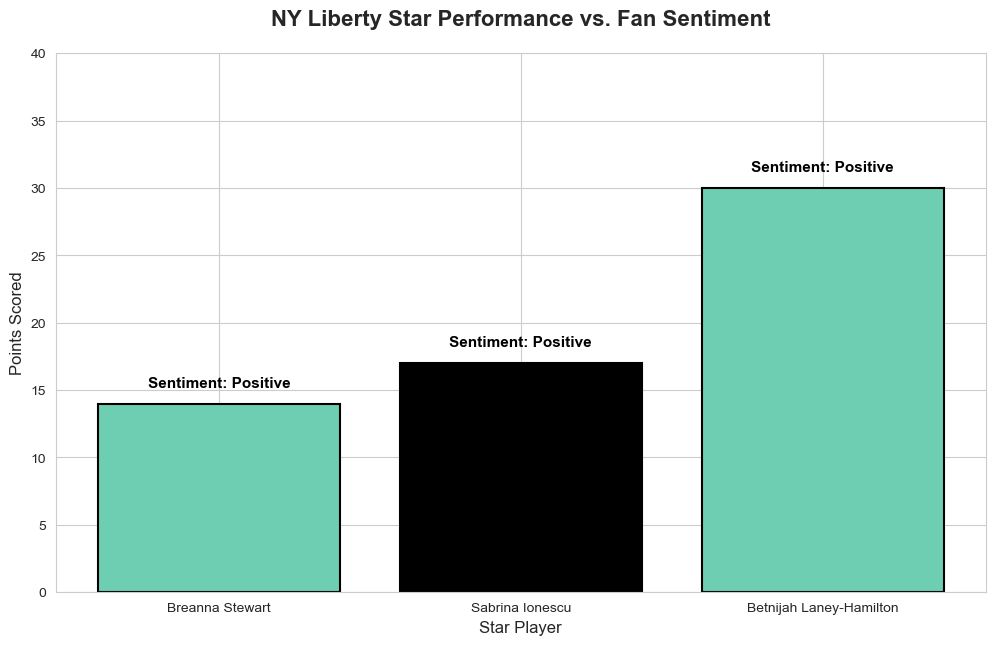

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean the data for plotting (removing duplicates)
df_plot = df_final.drop_duplicates(subset=['PLAYER_NAME', 'GAME_DATE']).copy()

# 2. Setup the "Liberty Seafoam" style
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
liberty_colors = ['#6ECEB2', '#000000', '#6ECEB2'] # Seafoam and Black

# 3. Create the bar chart
bars = plt.bar(df_plot['PLAYER_NAME'], df_plot['Points'], color=liberty_colors, edgecolor='black', linewidth=1.5)

# 4. Add the Sentiment labels on top of the bars
for bar, sentiment in zip(bars, df_plot['Sentiment']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'Sentiment: {sentiment}',
             ha='center', va='bottom', fontweight='bold', color='black', fontsize=11)

# 5. Titles and Formatting
plt.title('NY Liberty Star Performance vs. Fan Sentiment', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Points Scored', fontsize=12)
plt.xlabel('Star Player', fontsize=12)
plt.ylim(0, 40) # Give some space for the labels at the top

plt.show()

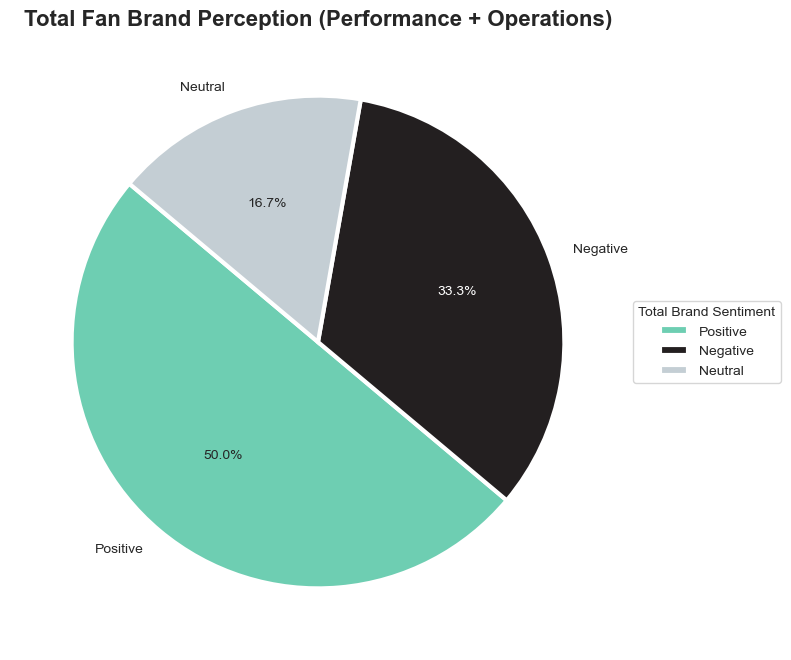

In [14]:
# 1. Query the FULL sentiment table, not just the joined player stats
with engine.connect() as conn:
    df_all_sentiment = pd.read_sql("SELECT Sentiment FROM Fact_Fan_Sentiment", conn)

topic_data = df_all_sentiment['Sentiment'].value_counts()

# 2. Create the Pie Chart
plt.figure(figsize=(10, 8))
colors = ['#6ECEB2', '#231F20', '#C4CED4'] # Seafoam, Black, Silver

patches, texts, autotexts = plt.pie(
    topic_data, 
    labels=topic_data.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    wedgeprops={'linewidth': 3, 'edgecolor': 'white'} 
)

# Fix text visibility
for i, patch in enumerate(patches):
    if topic_data.index[i] == 'Negative': # Targeting the Black slice specifically
        autotexts[i].set_color('white')

plt.legend(patches, topic_data.index, title="Total Brand Sentiment", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title('Total Fan Brand Perception (Performance + Operations)', fontsize=16, fontweight='bold')
plt.show()